# ZINC Michael acceptors

## Import necessary packages

In [1]:
import os
import pandas as pd
from rdkit import Chem
from rdkit.Chem import PandasTools
from rdkit.Chem import Draw
from tqdm import tqdm
# For parallel processing
from pandarallel import pandarallel

# Choose a tranche (chunk) to load
# Choose number of CPUs for parallel processsing
chunk = "01"
ncpu = 10

Failed to find the pandas get_adjustment() function to patch
Failed to patch pandas - PandasTools will have limited functionality


## Data collection / loading

Data was collected from 1/100 tranches of ZINC provided on the HuggingFace platform (https://huggingface.co/datasets/zpn/zinc20)

Before running this notebook, please download the appropriate tranche jsonl.gz file from https://huggingface.co/datasets/zpn/zinc20/tree/main/zinc_processed

Load the chunk selected (contains approx. 10M molecules as SMILES, SELFIES, ZINC_ID)

In [ ]:
# Takes ~ 1 minute to unzip and load (approx. 10M molecules)
file = os.path.join("ZINC",f"smiles_all_{chunk}_clean.jsonl.gz")
df = pd.read_json(file, lines=True)

In [3]:
print(df.shape)
df.head()

(10081800, 3)


,smiles,id,selfies
0,CC(C)c1cccc(c1)c2cccc3c2NC(=O)N(C3)C,ZINC001241740817_1,[C][C][Branch1][C][C][C][=C][C][=C][C][=Branch...
1,CC(C)c1cccc(c1)c2cccnc2OC(F)F,ZINC001241740844_1,[C][C][Branch1][C][C][C][=C][C][=C][C][=Branch...
2,Cc1c(ccc2n1ccn2)c3cccc(c3)C(C)C,ZINC001241740852_1,[C][C][=C][Branch1][N][C][=C][C][N][Ring1][=Br...
3,CC(C)c1cccc(c1)c2cc3cc[nH]c3nc2C(=O)OC,ZINC001241740861_1,[C][C][Branch1][C][C][C][=C][C][=C][C][=Branch...
4,CC(C)c1cccc(c1)c2ccc3c(c2)CNC(=O)C3(C)C,ZINC001241740910_1,[C][C][Branch1][C][C][C][=C][C][=C][C][=Branch...


## Filtering ZINC for Michael acceptors

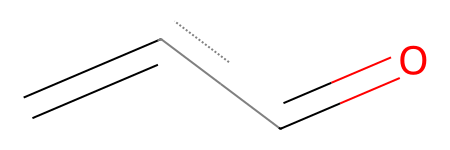

In [4]:
smarts = "O=CC=C"
patt = Chem.MolFromSmarts(smarts)
patt

In [5]:
# Takes ~ 3 minutes for full dataset
# (approx. 3 minutes per 10_000_000 compounds)
pandarallel.initialize(nb_workers=ncpu, progress_bar=True)
df["HasMatch"] = df["smiles"].parallel_apply(lambda x: Chem.MolFromSmiles(x).HasSubstructMatch(patt))
Michael_df = df[df["HasMatch"]==True]
del df # clear large df from memory
print(Michael_df.shape)
Michael_df.head()

INFO: Pandarallel will run on 10 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.


(182451, 4)


,smiles,id,selfies,HasMatch
2782,Cn1ccc2c1cccc2c3ccc(cc3)/C=C/C(=O)OC,ZINC001241823454_1,[C][N][C][=C][C][=C][Ring1][Branch1][C][=C][C]...,True
2783,Cn1ccc2c1cccc2c3ccc(cc3)/C=C\C(=O)OC,ZINC001241823455_1,[C][N][C][=C][C][=C][Ring1][Branch1][C][=C][C]...,True
3982,C=CC(=O)Oc1ccc(cc1)c2cnn(c2)C3CCCCC3,ZINC001241842986_1,[C][=C][C][=Branch1][C][=O][O][C][=C][C][=C][B...,True
4117,c1ccc(c(c1)/C=C/C(=O)[O-])c2cnn(c2)C3CCCCC3,ZINC001241844790_1,[C][=C][C][=C][Branch1][=C][C][=Branch1][Ring2...,True
4884,COc1cccc(c1Cl)c2ccccc2/C=C/C(=O)[O-],ZINC001241859054_1,[C][O][C][=C][C][=C][C][=Branch1][Branch1][=C]...,True


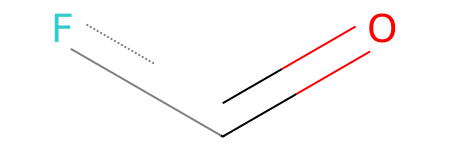

In [6]:
filter_smarts = ["O=C([OH])C=C","O=C([O-])C=C",
                 "O=C(F)","O=C(Cl)","O=C(Br)","O=C(I)",
                 "O=CC([OH])=C","O=CC=C[OH]",
                 "O=CC([NH2])=C","O=CC=C[NH2]",
                 "O=CC=CC=O"]
filter_mols = [Chem.MolFromSmarts(fs) for fs in filter_smarts]

# from rdkit.Chem.Draw import MolsToGridImage
# MolsToGridImage(mols=filter_mols, legends=filter_smarts, molsPerRow=4)
filter_mols[2]

In [7]:
# Can be relatively slow, ~ 1 minute
PandasTools.AddMoleculeColumnToFrame(Michael_df, smilesCol='smiles')
tqdm.pandas()
Michael_df["Filter"] = Michael_df["ROMol"].progress_apply(lambda x: any(x.HasSubstructMatch(patt) for patt in filter_mols))

Failed to patch pandas - unable to change molecule rendering
100%|██████████| 182451/182451 [00:02<00:00, 81385.90it/s]


In [8]:
Michael_df = Michael_df[Michael_df["Filter"]==False]
print(Michael_df.shape)
Michael_df.drop(["HasMatch","ROMol","Filter"], axis=1, inplace=True)
outfile = os.path.join("data","ZINC",f"ZINC_{chunk}_Michael.csv.gz")
Michael_df.to_csv(outfile,index=False,compression='gzip')
Michael_df.head()

(157278, 6)


,smiles,id,selfies
2782,Cn1ccc2c1cccc2c3ccc(cc3)/C=C/C(=O)OC,ZINC001241823454_1,[C][N][C][=C][C][=C][Ring1][Branch1][C][=C][C]...
2783,Cn1ccc2c1cccc2c3ccc(cc3)/C=C\C(=O)OC,ZINC001241823455_1,[C][N][C][=C][C][=C][Ring1][Branch1][C][=C][C]...
3982,C=CC(=O)Oc1ccc(cc1)c2cnn(c2)C3CCCCC3,ZINC001241842986_1,[C][=C][C][=Branch1][C][=O][O][C][=C][C][=C][B...
4947,COc1cccc(c1Cl)c2ccc(cc2)OC(=O)C=C,ZINC001241859695_1,[C][O][C][=C][C][=C][C][=Branch1][Branch1][=C]...
5427,C=CC(=O)Oc1ccc(cc1)c2ccc3c(c2)ncs3,ZINC001241871171_1,[C][=C][C][=Branch1][C][=O][O][C][=C][C][=C][B...


## Re-load dataframe and print out some molecules

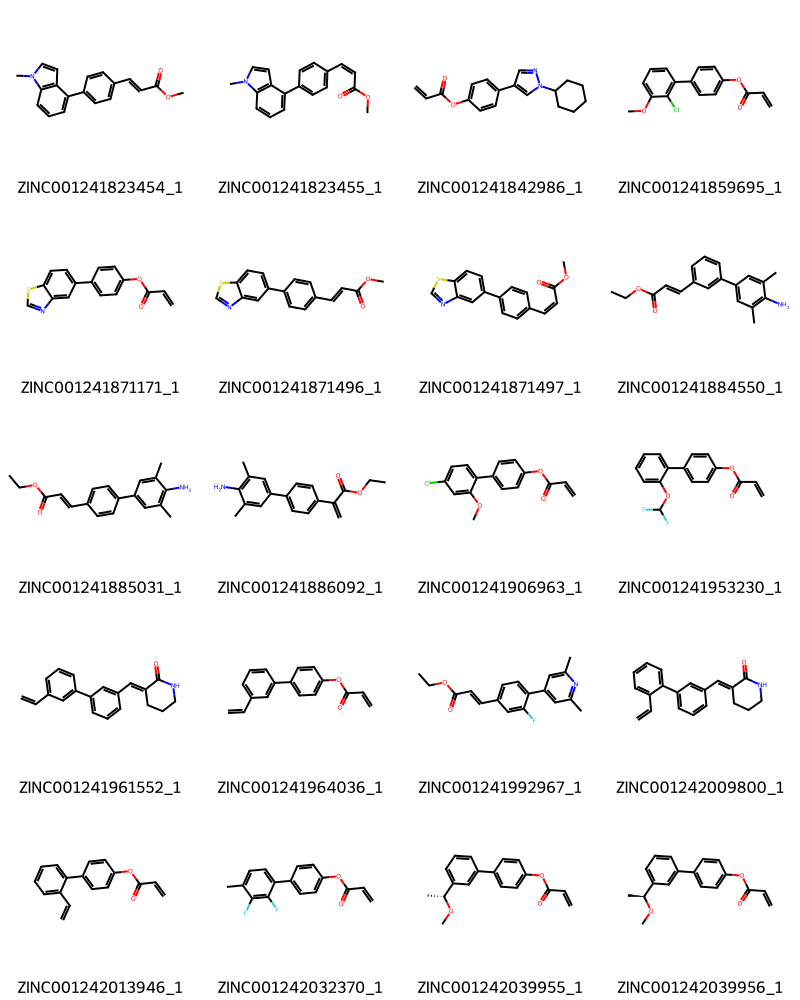

In [9]:
outfile = str(os.path.join("data","ZINC",f"ZINC_{chunk}_Michael.csv.gz"))
Michael_df = pd.read_csv(outfile, compression="gzip")

m = 20
mols = [Chem.MolFromSmiles(smi) for smi in Michael_df["smiles"].values[:m]]
ids = Michael_df["id"].values[:m]
Draw.MolsToGridImage(mols=mols, legends=ids.tolist(), molsPerRow=4, useSVG=True)

## Make train-valid-test splits and save to SMI format

In [10]:
# Train-validation-test split

import numpy as np
np.random.seed(42)

n_train = len(Michael_df) - 50_000
n_valid, n_test = 25_000, 25_000
smi_id = Michael_df[["smiles","id"]].values
np.random.shuffle(smi_id)
train = smi_id[:n_train].astype(str)
valid = smi_id[n_train:n_train+n_valid].astype(str)
test = smi_id[n_train+n_valid:].astype(str)

header = np.array([["SMILES","Name"]])
np.savetxt(os.path.join("data","ZINC","train.smi"),
            np.concatenate((header, train)), delimiter=" ", fmt="%s")
np.savetxt(os.path.join("data","ZINC","valid.smi"), 
           np.concatenate((header, valid)), delimiter=" ", fmt="%s")
np.savetxt(os.path.join("data","ZINC","test.smi"), 
           np.concatenate((header, test)), delimiter=" ", fmt="%s")

In [11]:
with open(os.path.join("data","ZINC","test.smi"), "r") as f:
    lines = f.readlines()[:10]
print("".join(lines))

SMILES Name
c1cc(cc(c1)N(=O)=O)/C=C\C(=O)NC2(CCOCC2)CF ZINC000492987504_1
CCc1cc(ncn1)N2CCC[C@@H](C2)NC(=O)/C(=C/c3ccc(cc3)F)/n4c(nnn4)C ZINC000732916437_1
C[C@H]\1c2c(cccc2Br)C(=O)/C1=C/c3c(cnn3C)C4CC4 ZINC000849244869_1
Cc1ccc(cc1)OCCOc2ccc(cc2C=C3C(=O)NC(=S)NC3=O)Br ZINC000002947697_1
C1COCC[NH+]1C/C=C\C(=O)N2CCN3[C@@H](C2)C(=O)NC3=O ZINC000866346369_1
Cn1nc(nn1)C(=O)N[C@@H]2CN(C[C@@H]2O)C(=O)/C=C/C3CC3 ZINC000969783813_1
CC(=C)[C@H](c1ccc(c(c1)F)F)NC(=O)/C=C/c2ccc(cc2)N(=O)=O ZINC000774542674_1
Cc1ccc(cc1C(=O)[O-])/C=C\C(=O)c2cc(ccc2SC)N(=O)=O ZINC001777406163_1
CCn1c(n[nH]c1=S)CCNC(=O)/C(=C/c2ccco2)/n3c(nnn3)c4ccccc4 ZINC000731441679_1



## Michael Acceptor Statistics

In [ ]:
# Report the number of amides, esters, ketones, aldehydes in this data set

# 1. Collect number of amides, esters, ketones, aldehydes 
# 2. Plot a bar chart or pie chart 

# AMIDE = C=CC(N)=O # IsAmide
# KETONE = C=CC(C)=O, C=CC(c)=O # IsKetone
# ESTER = C=CC(OC)=O, C=CC(Oc)=O # IsEster
# ALDEHYDE = C=CC([H])=O # IsAldehyde

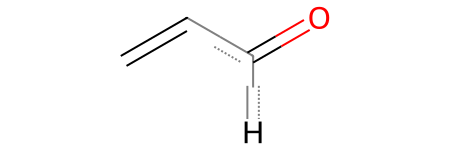

In [12]:
from rdkit import Chem
from rdkit.Chem import Draw
mol = Chem.MolFromSmarts("C=CC([H])=O")
mol

In [13]:
outfile = str(os.path.join("data","ZINC",f"ZINC_{chunk}_Michael.csv.gz"))
Michael_df = pd.read_csv(outfile, compression="gzip")
print(Michael_df.shape)
Michael_df.head()

(157278, 3)


,smiles,id,selfies
0,Cn1ccc2c1cccc2c3ccc(cc3)/C=C/C(=O)OC,ZINC001241823454_1,[C][N][C][=C][C][=C][Ring1][Branch1][C][=C][C]...
1,Cn1ccc2c1cccc2c3ccc(cc3)/C=C\C(=O)OC,ZINC001241823455_1,[C][N][C][=C][C][=C][Ring1][Branch1][C][=C][C]...
2,C=CC(=O)Oc1ccc(cc1)c2cnn(c2)C3CCCCC3,ZINC001241842986_1,[C][=C][C][=Branch1][C][=O][O][C][=C][C][=C][B...
3,COc1cccc(c1Cl)c2ccc(cc2)OC(=O)C=C,ZINC001241859695_1,[C][O][C][=C][C][=C][C][=Branch1][Branch1][=C]...
4,C=CC(=O)Oc1ccc(cc1)c2ccc3c(c2)ncs3,ZINC001241871171_1,[C][=C][C][=Branch1][C][=O][O][C][=C][C][=C][B...


Amides

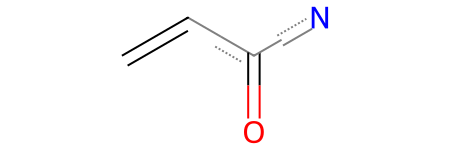

In [14]:
amide_smarts = "C=CC(=O)N"
amide_patt = Chem.MolFromSmarts(amide_smarts)
amide_patt

In [15]:
pandarallel.initialize(nb_workers=ncpu, progress_bar=True)
Michael_df["HasAmide"] = Michael_df["smiles"].parallel_apply(lambda x: Chem.MolFromSmiles(x).HasSubstructMatch(amide_patt))
Amide_df = Michael_df[Michael_df["HasAmide"]==True]
print(Amide_df.shape)
Amide_df.head()

INFO: Pandarallel will run on 10 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.


(111734, 4)


,smiles,id,selfies,HasAmide
12,C=Cc1cccc(c1)c2cccc(c2)/C=C/3\CCCNC3=O,ZINC001241961552_1,[C][=C][C][=C][C][=C][C][=Branch1][Ring2][=C][...,True
15,C=Cc1ccccc1c2cccc(c2)/C=C/3\CCCNC3=O,ZINC001242009800_1,[C][=C][C][=C][C][=C][C][=C][Ring1][=Branch1][...,True
25,c1cc(cc(c1)c2cccc(c2)Cl)/C=C/3\CCCNC3=O,ZINC001242145712_1,[C][=C][C][=Branch2][Ring1][Ring1][=C][C][=Bra...,True
38,Cc1cccc(c1F)c2cccc(c2)/C=C/3\CCCNC3=O,ZINC001242237663_1,[C][C][=C][C][=C][C][=Branch1][Branch1][=C][Ri...,True
94,C=C(c1ccccc1)c2cccc(c2)/C=C/3\CCCNC3=O,ZINC001242893302_1,[C][=C][Branch1][=Branch2][C][=C][C][=C][C][=C...,True


Aldehydes

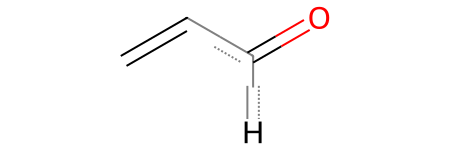

In [16]:
aldehyde_smarts = "C=CC([H])=O"
aldehyde_patt = Chem.MolFromSmarts(aldehyde_smarts)
aldehyde_patt

In [17]:
pandarallel.initialize(nb_workers=ncpu, progress_bar=True)
Michael_df["HasAldehyde"] = Michael_df["smiles"].parallel_apply(lambda x: Chem.MolFromSmiles(x).HasSubstructMatch(aldehyde_patt))
Aldehyde_df = Michael_df[Michael_df["HasAldehyde"]==True]
print(Aldehyde_df.shape)
Aldehyde_df.head()

INFO: Pandarallel will run on 10 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.


(0, 5)


,smiles,id,selfies,HasAmide,HasAldehyde


Esters

In [18]:
ester_smarts_1 = "C=CC(OC)=O"
ester_smarts_2 = "C=CC(Oc)=O"
ester_patt_1 = Chem.MolFromSmarts(ester_smarts_1)
ester_patt_2 = Chem.MolFromSmarts(ester_smarts_2)



In [19]:
pandarallel.initialize(nb_workers=ncpu, progress_bar=True)
Michael_df["HasEster"] = Michael_df["smiles"].parallel_apply(lambda x: Chem.MolFromSmiles(x).HasSubstructMatch(ester_patt_1) or Chem.MolFromSmiles(x).HasSubstructMatch(ester_patt_2))
ester_df = Michael_df[Michael_df["HasEster"]==True]
print(ester_df.shape)
ester_df.head()

INFO: Pandarallel will run on 10 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.


(16901, 6)


,smiles,id,selfies,HasAmide,HasAldehyde,HasEster
0,Cn1ccc2c1cccc2c3ccc(cc3)/C=C/C(=O)OC,ZINC001241823454_1,[C][N][C][=C][C][=C][Ring1][Branch1][C][=C][C]...,False,False,True
1,Cn1ccc2c1cccc2c3ccc(cc3)/C=C\C(=O)OC,ZINC001241823455_1,[C][N][C][=C][C][=C][Ring1][Branch1][C][=C][C]...,False,False,True
2,C=CC(=O)Oc1ccc(cc1)c2cnn(c2)C3CCCCC3,ZINC001241842986_1,[C][=C][C][=Branch1][C][=O][O][C][=C][C][=C][B...,False,False,True
3,COc1cccc(c1Cl)c2ccc(cc2)OC(=O)C=C,ZINC001241859695_1,[C][O][C][=C][C][=C][C][=Branch1][Branch1][=C]...,False,False,True
4,C=CC(=O)Oc1ccc(cc1)c2ccc3c(c2)ncs3,ZINC001241871171_1,[C][=C][C][=Branch1][C][=O][O][C][=C][C][=C][B...,False,False,True


Ketones

In [20]:
ketone_smarts_1 = "C=CC(C)=O"
ketone_smarts_2 = "C=CC(c)=O"
ketone_patt_1 = Chem.MolFromSmarts(ketone_smarts_1)
ketone_patt_2 = Chem.MolFromSmarts(ketone_smarts_2)

In [21]:
pandarallel.initialize(nb_workers=ncpu, progress_bar=True)
Michael_df["HasKetone"] = Michael_df["smiles"].parallel_apply(lambda x: Chem.MolFromSmiles(x).HasSubstructMatch(ketone_patt_1) or Chem.MolFromSmiles(x).HasSubstructMatch(ketone_patt_2))
ketone_df = Michael_df[Michael_df["HasKetone"]==True]
print(ketone_df.shape)
ketone_df.head()

INFO: Pandarallel will run on 10 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.


(28647, 7)


,smiles,id,selfies,HasAmide,HasAldehyde,HasEster,HasKetone
268,c1ccc(cc1)C[NH+]2CCC(=CC(=O)c3ccccc3)CC2,ZINC001249884224_1,[C][=C][C][=C][Branch1][Branch1][C][=C][Ring1]...,False,False,False,True
269,c1ccc(cc1)C[NH+]2CCCC(=CC(=O)c3ccccc3)C2,ZINC001249884520_1,[C][=C][C][=C][Branch1][Branch1][C][=C][Ring1]...,False,False,False,True
270,c1ccc(cc1)C(=O)C=C2CCN(CC2)c3ccccc3,ZINC001249884821_1,[C][=C][C][=C][Branch1][Branch1][C][=C][Ring1]...,False,False,False,True
271,COc1ccccc1C(=O)C=C2CCC(CC2)(F)F,ZINC001249888520_1,[C][O][C][=C][C][=C][C][=C][Ring1][=Branch1][C...,False,False,False,True
272,COc1ccccc1C(=O)C=CCCc2ccccc2,ZINC001249888611_1,[C][O][C][=C][C][=C][C][=C][Ring1][=Branch1][C...,False,False,False,True


Creating a pi chart to show the proportion of each functional group in the dataset

In [22]:
functional_group_cols = ['HasAmide', 'HasEster', 'HasKetone']
functional_group_counts = Michael_df[functional_group_cols].sum()
functional_group_proportions = functional_group_counts / len(Michael_df)

print("Counts:\n", functional_group_counts)
print("Proprtions:\n", functional_group_proportions)

Counts:
 HasAmide     111734
HasEster      16901
HasKetone     28647
dtype: int64
Proprtions:
 HasAmide     0.710424
HasEster     0.107459
HasKetone    0.182142
dtype: float64


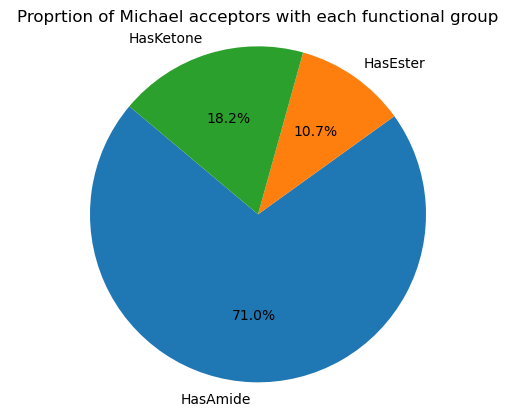

In [24]:
import matplotlib.pyplot as plt

plt.pie(functional_group_counts, labels=functional_group_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Proprtion of Michael acceptors with each functional group')
plt.axis('equal')
plt.show()




N.B. The reason the number of Michael acceptors, and the distribution of functional groups in tranche 1 (second tranche) is substantially different from tranche 0 is because this ZINC dataset is not shuffled. In other words, this ZINC data has a structured order where the ZINC molecule IDs are, for example, ordered alphanumerically (or some other way) that causes the compounds closer in index to one another to have more similar molecular structures.

Because of this, you must sample data (randomly) from all tranches in order to get a diverse and representative (shuffled) subset of compounds, instead of selecting the nth tranche, which would give a substantially less diverse and more biased set of molecular structures.